# Hydro Balances

This notebook retrieves and visualises Nordic hydro balance forecasts from the PointConnect timeseries database. The hydro balance $B_c(t)$ for country $c$ at time $t$ represents the deviation of reservoir filling relative to seasonal norms, expressed in GWh. Positive values indicate above-normal storage; negative values indicate deficit. The analysis partitions each series into observed actuals ($t < t_{\text{now}}$) and forecast trajectories ($t \geq t_{\text{now}}$).

## Imports

Load required libraries and the database query interface.

In [7]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd())))
from functions.sql_data import get_sql_query
import pandas as pd
import matplotlib.pyplot as plt

## Parameters

Define the PointConnect curve identifiers for Nordic hydro balance forecasts. Each entry maps an ISO country code $c$ to its corresponding `CurveId` in `pub.Timeseries1_v02`.

In [13]:
hydro_balance_forecasts_ids: dict[str, int] = {
    "NO": 103281914,
    "SE": 103281910,
    "FIN": 103281918,
    "Nordic": 103281922
}

start_date = "2021-01-01"

## Data Collection

For each country $c \in \{$NO, SE, FIN, Nordic$\}$, retrieve the latest hydro balance forecast from `pub.Timeseries1_v02` using the curve identifiers defined above. The query filters on `IsLatestForecast = 1` to obtain the most recent revision.

In [14]:
hydro_balances = {}

tomorrow = (pd.Timestamp.now(tz="UTC").normalize() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

for countrycode in list(hydro_balance_forecasts_ids.keys()):

    country_query = f"""
        SELECT ValueDateUTC, ForecastDateUTC, Value
        FROM pub.Timeseries1_v02
        WHERE CurveId = {hydro_balance_forecasts_ids[countrycode]}
        AND IsLatestForecast = 1
        AND ValueDateUTC >= '{start_date}'
        ORDER BY ValueDateUTC ASC
    """

    country_data = get_sql_query(country_query)
    country_data["ValueDateUTC"] = pd.to_datetime(country_data["ValueDateUTC"], utc=True)
    country_data["ForecastDateUTC"] = pd.to_numeric(country_data["ForecastDateUTC"], errors="coerce")
    country_data["CountryCode"] = countrycode

    print(f"Data for {countrycode}:")
    display(country_data)

    hydro_balances[countrycode] = country_data

hydro_balances_df = pd.concat(hydro_balances.values(), ignore_index=True)
print("Combined Hydro Balances DataFrame:")
display(hydro_balances_df)

Data for NO:


,ValueDateUTC,ForecastDateUTC,Value,CountryCode
0,2021-01-01 00:00:00+00:00,1609459200000000000,13358.658543,NO
1,2021-01-02 00:00:00+00:00,1609545600000000000,12837.429480,NO
2,2021-01-03 00:00:00+00:00,1609632000000000000,12286.112818,NO
3,2021-01-04 00:00:00+00:00,1609761600000000000,10965.581085,NO
4,2021-01-05 00:00:00+00:00,1609848000000000000,10331.281953,NO
...,...,...,...,...
2336,2027-05-26 00:00:00+00:00,1780876800000000000,-7195.475138,NO
2337,2027-05-27 00:00:00+00:00,1780876800000000000,-7155.235826,NO
2338,2027-05-28 00:00:00+00:00,1780876800000000000,-7058.048389,NO
2339,2027-05-29 00:00:00+00:00,1780876800000000000,-6995.804831,NO


Data for SE:


,ValueDateUTC,ForecastDateUTC,Value,CountryCode
0,2021-01-01 00:00:00+00:00,1609459200000000000,5838.548455,SE
1,2021-01-02 00:00:00+00:00,1609545600000000000,5540.983492,SE
2,2021-01-03 00:00:00+00:00,1609632000000000000,5227.228229,SE
3,2021-01-04 00:00:00+00:00,1609718400000000000,4871.679465,SE
4,2021-01-05 00:00:00+00:00,1609848000000000000,4551.003801,SE
...,...,...,...,...
2336,2027-05-26 00:00:00+00:00,1780876800000000000,-447.611511,SE
2337,2027-05-27 00:00:00+00:00,1780876800000000000,-405.917664,SE
2338,2027-05-28 00:00:00+00:00,1780876800000000000,-454.961318,SE
2339,2027-05-29 00:00:00+00:00,1780876800000000000,-492.398671,SE


Data for FIN:


,ValueDateUTC,ForecastDateUTC,Value,CountryCode
0,2021-01-01 00:00:00+00:00,1609459200000000000,797.986360,FIN
1,2021-01-02 00:00:00+00:00,1609545600000000000,855.191662,FIN
2,2021-01-03 00:00:00+00:00,1609632000000000000,807.585956,FIN
3,2021-01-04 00:00:00+00:00,1609718400000000000,773.913738,FIN
4,2021-01-05 00:00:00+00:00,1609804800000000000,729.359064,FIN
...,...,...,...,...
2336,2027-05-26 00:00:00+00:00,1780876800000000000,-685.643639,FIN
2337,2027-05-27 00:00:00+00:00,1780876800000000000,-696.420165,FIN
2338,2027-05-28 00:00:00+00:00,1780876800000000000,-699.549690,FIN
2339,2027-05-29 00:00:00+00:00,1780876800000000000,-693.488616,FIN


Data for Nordic:


,ValueDateUTC,ForecastDateUTC,Value,CountryCode
0,2021-01-01 00:00:00+00:00,1609502400000000000,19995.193358,Nordic
1,2021-01-02 00:00:00+00:00,1609588800000000000,19233.604634,Nordic
2,2021-01-03 00:00:00+00:00,1609675200000000000,18320.927003,Nordic
3,2021-01-04 00:00:00+00:00,1609761600000000000,16611.174288,Nordic
4,2021-01-05 00:00:00+00:00,1609848000000000000,15611.644818,Nordic
...,...,...,...,...
2336,2027-05-26 00:00:00+00:00,1780876800000000000,-8328.730289,Nordic
2337,2027-05-27 00:00:00+00:00,1780876800000000000,-8257.573655,Nordic
2338,2027-05-28 00:00:00+00:00,1780876800000000000,-8212.559397,Nordic
2339,2027-05-29 00:00:00+00:00,1780876800000000000,-8181.692118,Nordic


Combined Hydro Balances DataFrame:


,ValueDateUTC,ForecastDateUTC,Value,CountryCode
0,2021-01-01 00:00:00+00:00,1609459200000000000,13358.658543,NO
1,2021-01-02 00:00:00+00:00,1609545600000000000,12837.429480,NO
2,2021-01-03 00:00:00+00:00,1609632000000000000,12286.112818,NO
3,2021-01-04 00:00:00+00:00,1609761600000000000,10965.581085,NO
4,2021-01-05 00:00:00+00:00,1609848000000000000,10331.281953,NO
...,...,...,...,...
9359,2027-05-26 00:00:00+00:00,1780876800000000000,-8328.730289,Nordic
9360,2027-05-27 00:00:00+00:00,1780876800000000000,-8257.573655,Nordic
9361,2027-05-28 00:00:00+00:00,1780876800000000000,-8212.559397,Nordic
9362,2027-05-29 00:00:00+00:00,1780876800000000000,-8181.692118,Nordic


## Visualization

Plot observed balances (solid) and forecast trajectories (dashed) for each country. The partition uses $t_{\text{now}} + 1\text{d}$ as the boundary between actuals and forecasts.

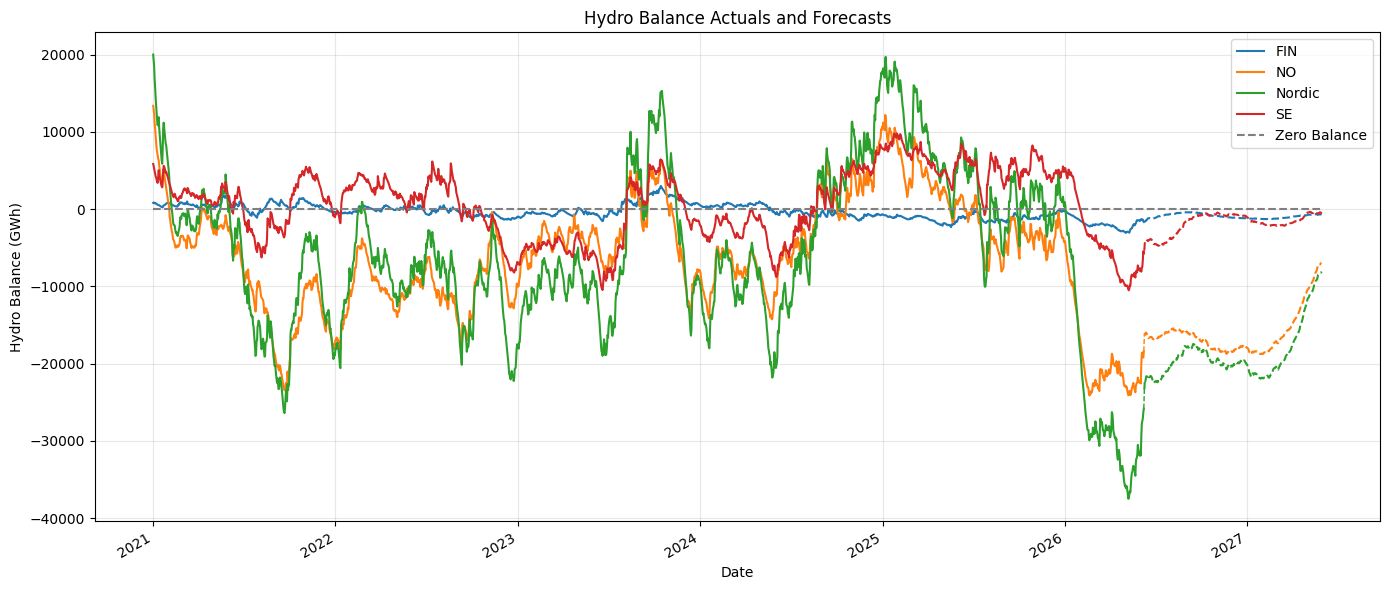

In [16]:
tomorrow = (pd.Timestamp.now(tz="UTC").normalize() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
actual_data = hydro_balances_df[hydro_balances_df["ValueDateUTC"] < tomorrow]
forecast_data = hydro_balances_df[hydro_balances_df["ValueDateUTC"] >= tomorrow]

fig, ax = plt.subplots(figsize=(14, 6))

for (i, (country, group)) in enumerate(actual_data.groupby("CountryCode")):
    ax.plot(group["ValueDateUTC"], group["Value"], label=country, color=plt.cm.tab10(i % 10))

for (i, (country, group)) in enumerate(forecast_data.groupby("CountryCode")):
    ax.plot(group["ValueDateUTC"], group["Value"], linestyle="dashed", color=plt.cm.tab10(i % 10))

# Connect last actual to first forecast with a dashed line
for (i, country) in enumerate(sorted(hydro_balances_df["CountryCode"].unique())):
    country_actual = actual_data[actual_data["CountryCode"] == country]
    country_forecast = forecast_data[forecast_data["CountryCode"] == country]
    if not country_actual.empty and not country_forecast.empty:
        last_actual = country_actual.iloc[-1]
        first_forecast = country_forecast.iloc[0]
        ax.plot(
            [last_actual["ValueDateUTC"], first_forecast["ValueDateUTC"]],
            [last_actual["Value"], first_forecast["Value"]],
            linestyle="dashed", color=plt.cm.tab10(i % 10), linewidth=1
        )

ax.hlines(0, xmin=hydro_balances_df["ValueDateUTC"].min(), xmax=hydro_balances_df["ValueDateUTC"].max(), colors="gray", linestyles="dashed", label="Zero Balance")

ax.set_xlabel("Date")
ax.set_ylabel("Hydro Balance (GWh)")
ax.set_title("Hydro Balance Actuals and Forecasts")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()